In [24]:
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

In [26]:
# Cargar la imagen
im = imageio.imread('RxMano.jpeg')

# Si la imagen tiene 3 canales (RGB), convertirla a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)

In [27]:
# Observar la forma y tipo de dato
print('Forma de la imagen:', im.shape)
print('Tipo de dato:', im.dtype)
print('Valor mínimo:', im.min())
print('Valor máximo:', im.max())

# Determinar si es RGB o escala de grises
if len(im.shape) == 2:
    print('La imagen es en escala de grises')
elif len(im.shape) == 3:
    print('La imagen es RGB con', im.shape[2], 'canales')

Forma de la imagen: (297, 170)
Tipo de dato: uint8
Valor mínimo: 0
Valor máximo: 229
La imagen es en escala de grises


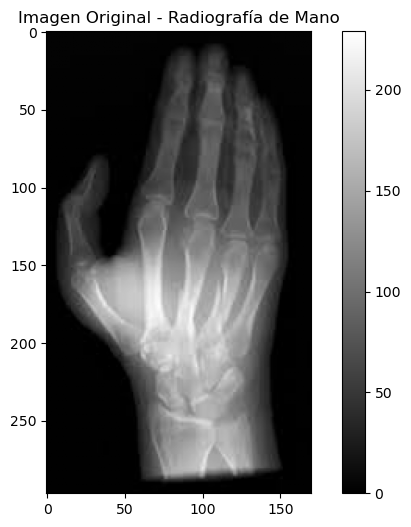

In [28]:
# Mostrar la imagen
plt.figure(figsize=(8, 6))
plt.imshow(im, cmap='gray')
plt.title('Imagen Original - Radiografía de Mano')
plt.colorbar()
plt.show()

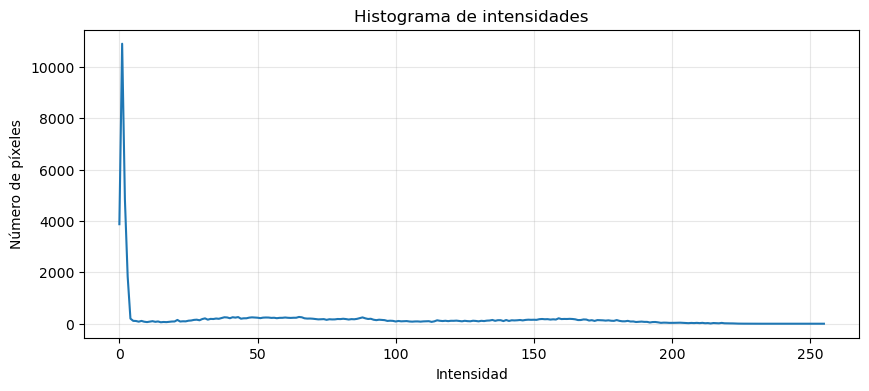

In [29]:
# Crear un histograma
hist = ndi.histogram(im, min=0, max=255, bins=256)

# Dibujar el histograma
plt.figure(figsize=(10, 4))
plt.plot(hist)
plt.xlabel('Intensidad')
plt.ylabel('Número de píxeles')
plt.title('Histograma de intensidades')
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
# Aplicar un umbral para seleccionar región de interés (hueso)
# Observando el histograma, elegimos un umbral apropiado
umbral = 150 # Ajusta según tu histograma

# Crear máscara binaria
mask_bone = im >= umbral

print(f'Umbral utilizado: {umbral}')
print(f'Píxeles en la máscara: {mask_bone.sum()}')
print(f'Porcentaje de la imagen: {(mask_bone.sum() / mask_bone.size) * 100:.2f}%')

Umbral utilizado: 150
Píxeles en la máscara: 6775
Porcentaje de la imagen: 13.42%


In [46]:
# Aplicar la máscara usando np.where
# Mantener los píxeles donde la máscara es True, poner 0 donde es False
im_bone = np.where(mask_bone, im, 0)

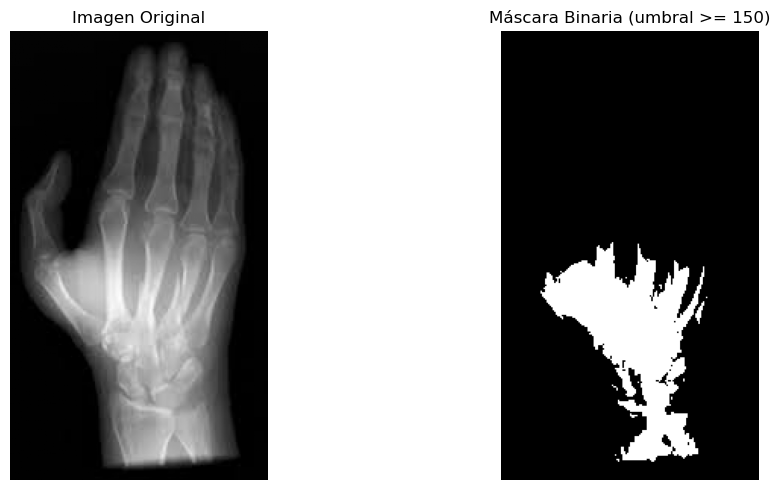

In [47]:
# Mostrar la imagen original y la máscara
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(im, cmap='gray')
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].imshow(mask_bone, cmap='gray')
axes[1].set_title(f'Máscara Binaria (umbral >= {umbral})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

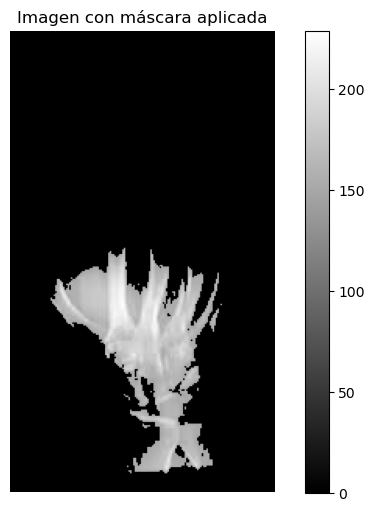

In [49]:
# Mostrar la imagen enmascarada 
plt.figure(figsize=(8, 6))
plt.imshow(im_bone, cmap='gray')
plt.title('Imagen con máscara aplicada')
plt.colorbar()
plt.axis('off')
plt.show()

In [50]:
# Aplicar dilatación sobre la máscara
mask_dilate = ndi.binary_dilation(mask_bone, iterations=5)

print(f'Píxeles en máscara original: {mask_bone.sum()}')
print(f'Píxeles en máscara dilatada: {mask_dilate.sum()}')
print(f'Incremento: {mask_dilate.sum() - mask_bone.sum()} píxeles')

Píxeles en máscara original: 6775
Píxeles en máscara dilatada: 10286
Incremento: 3511 píxeles


In [51]:
# Aplicar cierre sobre la máscara
mask_closed = ndi.binary_closing(mask_bone, iterations=5)

print(f'Píxeles en máscara cerrada: {mask_closed.sum()}')

Píxeles en máscara cerrada: 7791


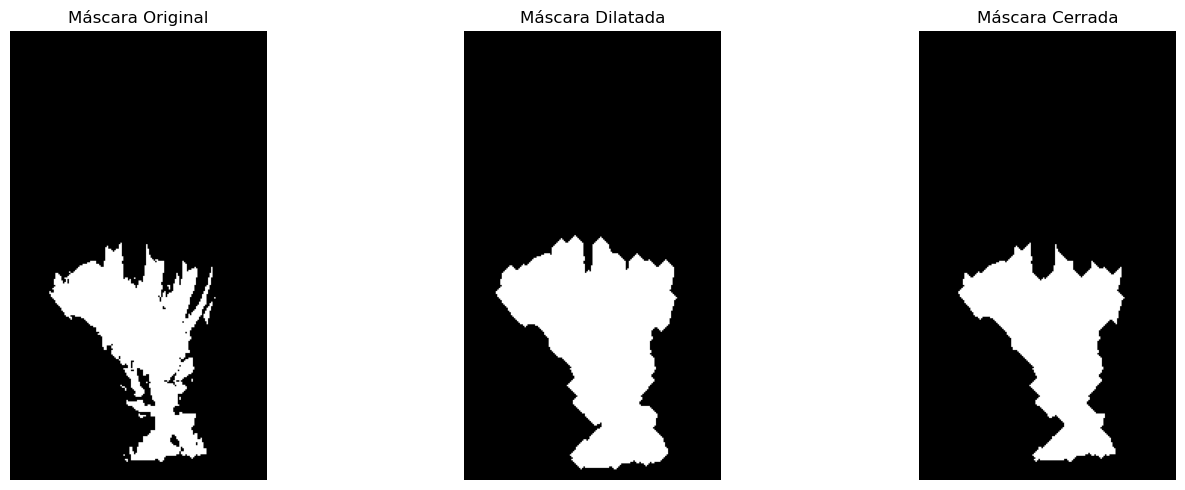

In [52]:
# Comparar las tres máscaras
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mask_bone, cmap='gray')
axes[0].set_title('Máscara Original')
axes[0].axis('off')

axes[1].imshow(mask_dilate, cmap='gray')
axes[1].set_title('Máscara Dilatada')
axes[1].axis('off')

axes[2].imshow(mask_closed, cmap='gray')
axes[2].set_title('Máscara Cerrada')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [53]:
# Crear un kernel de media 3x3
weights = np.array([[0.11, 0.11, 0.11],
                     [0.11, 0.11, 0.11],
                     [0.11, 0.11, 0.11]])

# También se puede hacer así:
# weights = np.ones((3, 3)) / 9

print("Kernel de media 3x3:")
print(weights)
print(f"Suma del kernel: {weights.sum():.2f}")

Kernel de media 3x3:
[[0.11 0.11 0.11]
 [0.11 0.11 0.11]
 [0.11 0.11 0.11]]
Suma del kernel: 0.99


In [54]:
# Aplicar convolución con el filtro de media
im_filt = ndi.convolve(im, weights)

print("Filtro de media aplicado")

Filtro de media aplicado


In [55]:
# Crear kernel de sharpening (realce de bordes)
kernel_sharpening = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])

print("Kernel de sharpening:")
print(kernel_sharpening)
print(f"Suma del kernel: {kernel_sharpening.sum()}")# Aplicar filtro de sharpening
im_sharp = ndi.convolve(im, kernel_sharpening)

print("Filtro de sharpening aplicado")

Kernel de sharpening:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]
Suma del kernel: 1


In [56]:
# Aplicar filtro de sharpening
im_sharp = ndi.convolve(im, kernel_sharpening)

print("Filtro de sharpening aplicado")

Filtro de sharpening aplicado


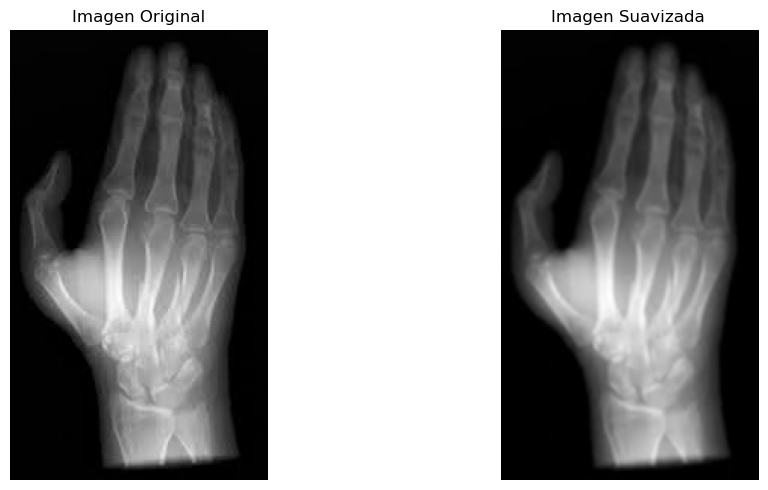

In [58]:
# Comparar imagen original y suavizada
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(im, cmap='gray')
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].imshow(im_filt, cmap='gray')
axes[1].set_title('Imagen Suavizada ')
axes[1].axis('off')

plt.tight_layout()
plt.show()

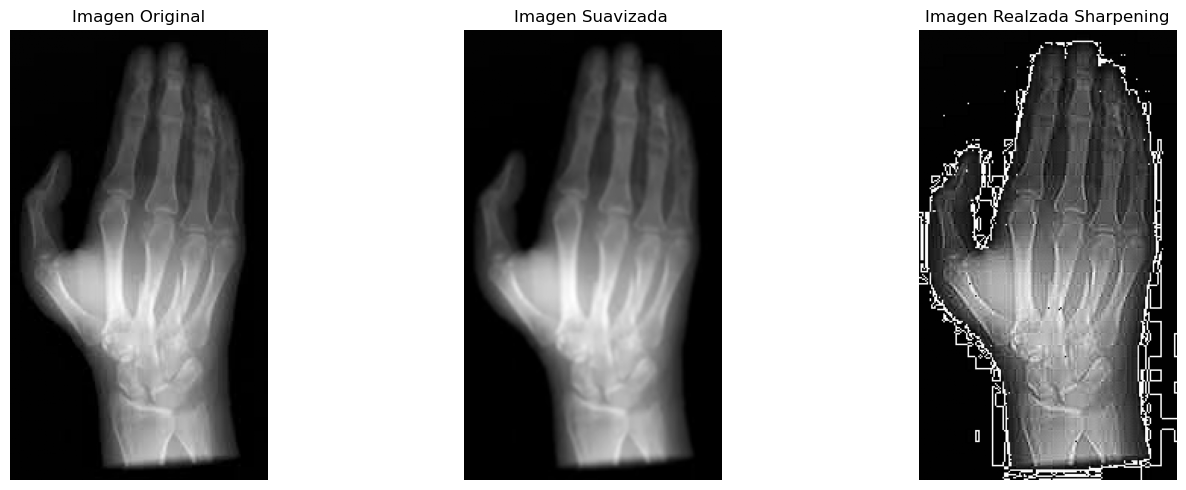

In [60]:
# Comparar las tres imágenes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im, cmap='gray')
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].imshow(im_filt, cmap='gray')
axes[1].set_title('Imagen Suavizada ')
axes[1].axis('off')

axes[2].imshow(im_sharp, cmap='gray')
axes[2].set_title('Imagen Realzada Sharpening')
axes[2].axis('off')

plt.tight_layout()
plt.show()